# Disease trajectories and patient fates

ICU patients do not all start at the same point, and their courses diverge: some deteriorate, others recover.
This tutorial orders patients along such courses in the first 48 hours of ICU stays of the PhysioNet 2012 challenge {cite}`silva2012predicting` {cite}`goldberger2000physiobank`.
We connect patients with similar hourly time series in a graph using dynamic time warping, order them by a pseudotime, summarize how groups of patients connect, follow how they move between states hour by hour, and estimate for every patient the probability of ending in a state of deterioration or recovery with CellRank {cite}`lange2022cellrank`.

## Environment setup

In [1]:
import warnings

warnings.filterwarnings("ignore")

import anndata as ad
import cellrank as cr
import ehrapy as ep
import ehrdata as ed
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

ep.settings.verbosity = "error"
cr.settings.logging_level = "ERROR"

In [2]:
%matplotlib inline

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
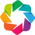

In [3]:
import holoviews as hv

hv.extension("bokeh")

## Data

The PhysioNet 2012 data holds 37 variables recorded hourly, so `.X` has the shape patients × variables × hours.
Static information such as age, ICU type (`ICUType`), the admission severity scores SOFA and SAPS-I and the outcome `In-hospital_death` is in `obs`.
We describe every patient by eight variables that are measured in most patients and often enough to form a time series: vital signs, the Glasgow Coma Scale (GCS), urine output, the fraction of inspired oxygen (FiO2) and the blood pH.

In [4]:
edata = ed.dt.physionet2012()
edata.obs["outcome"] = edata.obs["In-hospital_death"].map({0: "survived", 1: "died"}).astype("category")
variables = ["HR", "MAP", "NIMAP", "Temp", "GCS", "Urine", "FiO2", "pH"]

Dynamic time warping compares every pair of patients, so its cost grows with the square of the number of patients.
We therefore work with a random sample of 400 ICU stays and keep the patients with a value in at least half of the 48 hours.

:::{seealso}
The {doc}`cohort tutorial </tutorials/notebooks/cohort>` defines a cohort by inclusion criteria and handles implausible values in depth.
:::

In [5]:
rng = np.random.default_rng(0)
edata = edata[np.sort(rng.choice(edata.n_obs, 400, replace=False))].copy()
edata = edata[:, variables].copy()
ep.pp.qc_metrics(edata, time_key="time_value")
ep.pp.filter_observations(edata, query="measured_timepoints_pct >= 50")

plausible = {"HR": (1, 300), "MAP": (1, 300), "NIMAP": (1, 300), "Temp": (25, 45), "pH": (6.5, 8)}
for var, (low, high) in plausible.items():
    values = edata.X[:, edata.var_names.get_loc(var)]
    values[(values < low) | (values > high)] = np.nan
edata

EHRData object with n_obs × n_vars × n_t = 395 × 8 × 48
    obs: 'set', 'Age', 'Gender', 'Height', 'ICUType', 'SAPS-I', 'SOFA', 'Length_of_stay', 'Survival', 'In-hospital_death', 'outcome', 'missing_values_abs', 'missing_values_pct', 'entropy_of_missingness', 'measured_timepoints_abs', 'measured_timepoints_pct', 'first_measured_time', 'last_measured_time'
    var: 'Parameter', 'missing_values_abs', 'missing_values_pct', 'entropy_of_missingness', 'mean', 'median', 'standard_deviation', 'min', 'max', 'iqr_outliers', 'measured_obs_pct', 'median_interval'
    tem: '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47'
    shape of .X: (395, 8, 48)

## A patient graph from dynamic time warping

{func}`~ehrapy.preprocessing.scale_norm` gives every variable a mean of 0 and a standard deviation of 1, so that all variables contribute equally to the distances.
With `metric="dtw"`, {func}`~ehrapy.preprocessing.neighbors` compares the time series of two patients variable by variable with dynamic time warping, which aligns courses that are shifted or stretched in time before comparing them.
It skips missing hours, so the time series need no imputation, and connects every patient to the 15 most similar ones.

In [6]:
edata.layers["scaled"] = edata.X.copy()
ep.pp.scale_norm(edata, layer="scaled")

In [7]:
%%time
ep.pp.neighbors(edata, metric="dtw", use_rep="scaled")

CPU times: user 58.1 s, sys: 341 ms, total: 58.4 s
Wall time: 56.1 s


For comparison, we build the usual graph from the Euclidean distance between principal components, which compares patients hour by hour.
PCA needs a value in every hour, so {func}`~ehrapy.preprocessing.locf_impute` first carries the last value forward.
`key_added` stores this graph next to the DTW graph.

In [8]:
%%time
edata.layers["imputed"] = edata.layers["scaled"].copy()
ep.pp.locf_impute(edata, layer="imputed", fallback_method="mean")
ep.pp.pca(edata, layer="imputed")
ep.pp.neighbors(edata, key_added="euclidean")

CPU times: user 7.82 s, sys: 7.1 ms, total: 7.83 s
Wall time: 155 ms


We compare how many neighbours both graphs share and how well the share of neighbours who died separates patients who died from those who survived, as the area under the ROC curve (AUC).

In [9]:
died = edata.obs["In-hospital_death"].to_numpy()
graphs = {"dtw": edata.obsp["distances"] > 0, "euclidean": edata.obsp["euclidean_distances"] > 0}
shared = graphs["dtw"].multiply(graphs["euclidean"]).sum() / graphs["dtw"].sum()
print(f"Neighbours shared by both graphs: {shared:.0%}")
pd.Series(
    {name: roc_auc_score(died, (graph @ died) / graph.sum(axis=1).A1) for name, graph in graphs.items()},
    name="AUC of neighbours who died",
).round(2)

Neighbours shared by both graphs: 38%


dtw          0.76
euclidean    0.77
Name: AUC of neighbours who died, dtype: float64

The two graphs share only 38% of their neighbours, so the distance decides whom a patient is compared with.
Both place patients near others with the same outcome about equally well, with an AUC of 0.76 for DTW and 0.77 for the Euclidean graph, but DTW took about a minute instead of a fraction of a second.
The comparison is not entirely even, since DTW used the observed values with their gaps and the Euclidean graph imputed values.

:::{admonition} When is dynamic time warping worth it?
:class: tip
Use Euclidean distances between principal components by default, which take seconds even for thousands of patients.
Use `metric="dtw"` when the same course can start at different times, for example when the time axis starts at hospital admission but the event of interest happens at different hours, and when the cohort is small: here it took about a minute for 400 patients and would take 25 times as long for 2,000.
Here every time series starts at ICU admission, so aligning them in time adds little.
:::

The rest of this tutorial uses the DTW graph.
{func}`~ehrapy.tools.umap` embeds it in two dimensions for plotting.

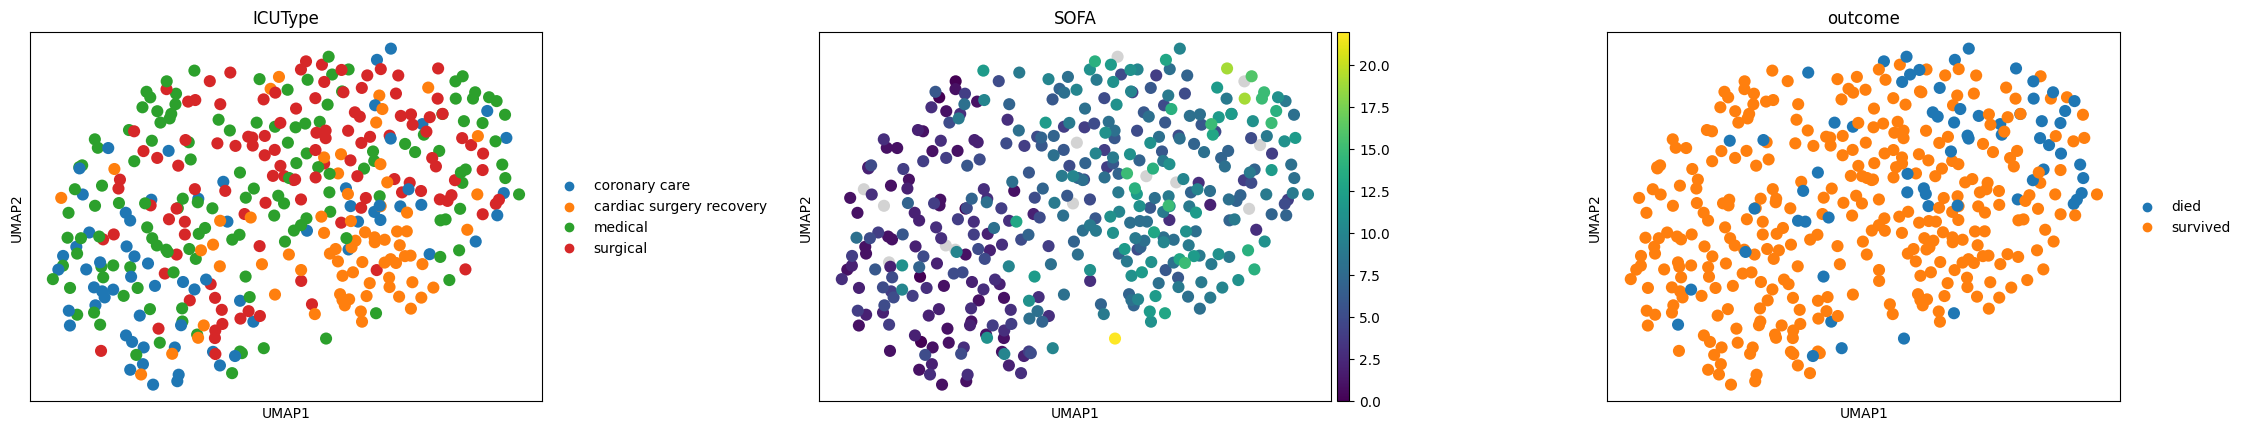

In [10]:
ep.tl.umap(edata)
ep.pl.umap(edata, color=["ICUType", "SOFA", "outcome"], wspace=0.4)

Patients with high SOFA scores and most of the deaths lie on the right of the embedding, and the patients recovering from cardiac surgery gather in its lower right.

## Pseudotime

{func}`~ehrapy.tools.diffmap` computes a diffusion map of the graph {cite}`Coifman2005` {cite}`Haghverdi2015`, whose first components follow the main continuous axes of variation between patients.

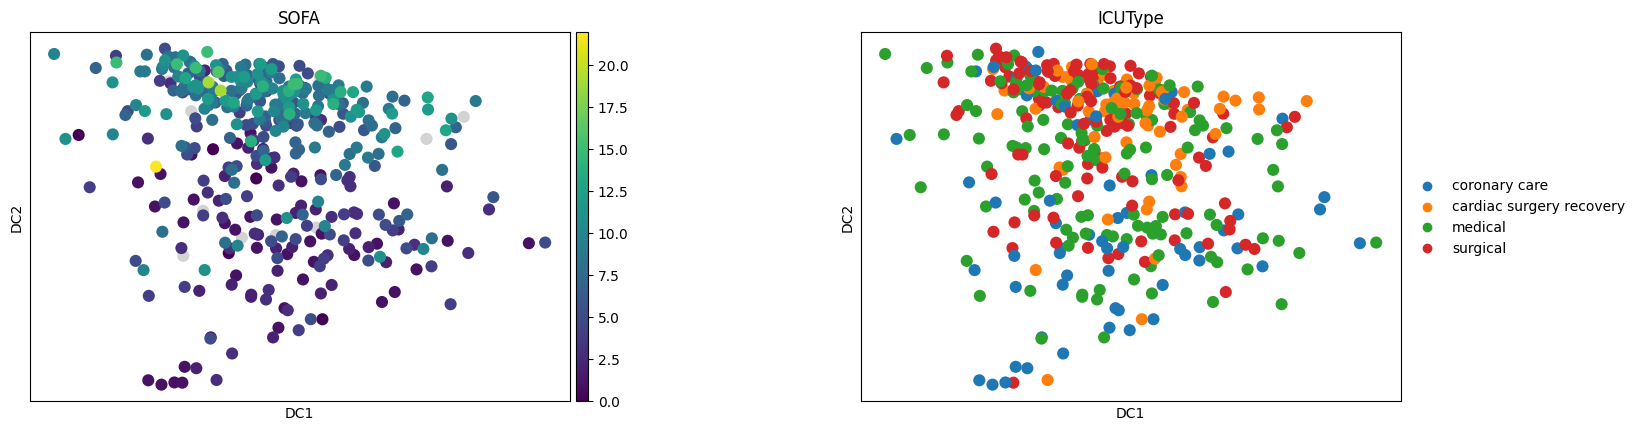

In [11]:
ep.tl.diffmap(edata)
ep.pl.diffmap(edata, color=["SOFA", "ICUType"], wspace=0.4)

High SOFA scores concentrate at the top left of the first two diffusion components, while patients with low scores spread out below.

{func}`~ehrapy.tools.dpt` orders all patients by their diffusion distance from a root patient, the diffusion pseudotime {cite}`Haghverdi2016`.
We choose the patient at the low-SOFA end of the first diffusion component as the root, so that pseudotime increases with illness severity.

:::{important}
Pseudotime is a position along a course of similar patients, not a time in hours: patients far along it look like patients who progressed far, whenever they were measured.
Since the root was chosen by the SOFA score, its relation to severity is partly built in.
:::

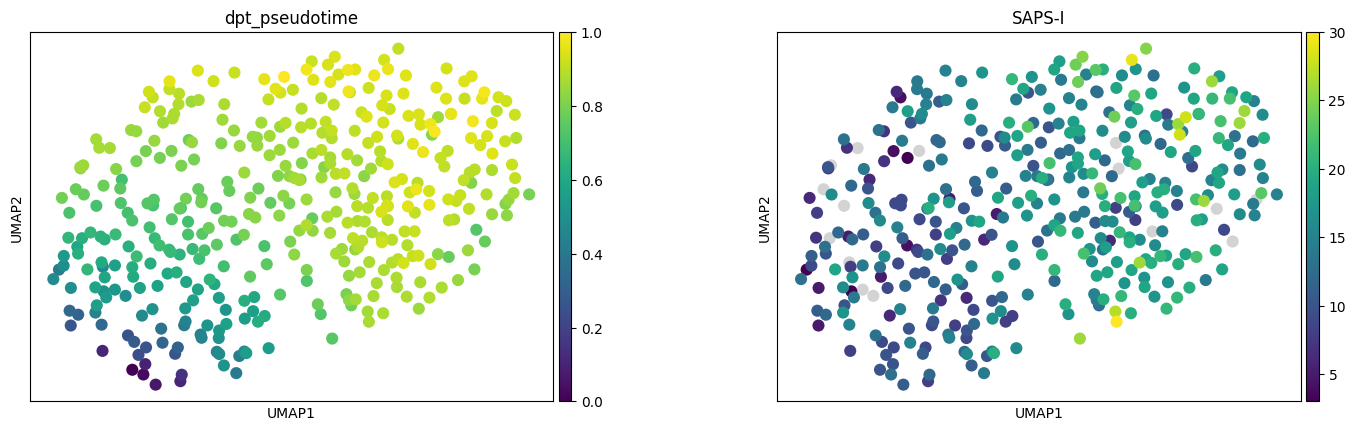

In [12]:
dc1 = pd.Series(edata.obsm["X_diffmap"][:, 1], index=edata.obs_names)
edata.uns["iroot"] = int(np.argmin(np.sign(dc1.corr(edata.obs["SOFA"], method="spearman")) * dc1))
ep.tl.dpt(edata)
ep.pl.umap(edata, color=["dpt_pseudotime", "SAPS-I"], wspace=0.3)

Pseudotime rises from the lower left of the embedding, where patients with low SAPS-I scores lie, to the right, where the sickest patients are.

## Connections between patient groups

{func}`~ehrapy.tools.leiden` divides the graph into groups of similar patients, and {func}`~ehrapy.tools.paga` measures how strongly every two groups are connected {cite}`Wolf2019`.
{func}`~ehrapy.plot.paga` draws the groups as nodes, colored by their in-hospital mortality and their mean pseudotime, with thicker edges for stronger connections.

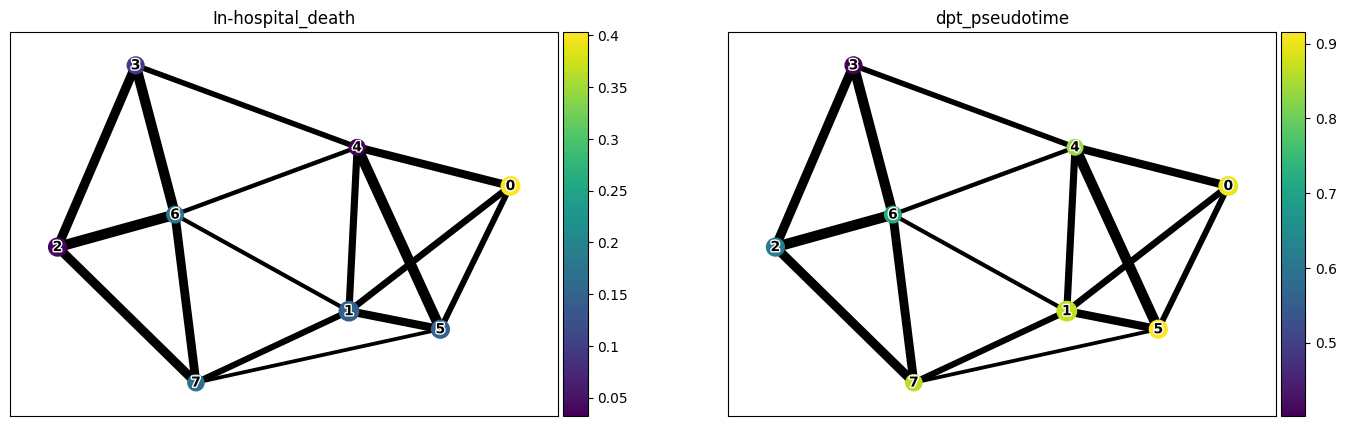

In [13]:
ep.tl.leiden(edata, resolution=1.0)
ep.tl.paga(edata, groups="leiden")
ep.pl.paga(edata, color=["In-hospital_death", "dpt_pseudotime"], threshold=0.3, fontoutline=2, cmap="viridis")

In [14]:
edata.obs.groupby("leiden", observed=True).agg(
    patients=("outcome", "size"),
    died_pct=("In-hospital_death", lambda x: round(100 * x.mean(), 1)),
    cardiac_surgery_pct=("ICUType", lambda x: round(100 * (x == "cardiac surgery recovery").mean(), 1)),
    pseudotime=("dpt_pseudotime", "median"),
    SOFA=("SOFA", "median"),
)

,patients,died_pct,cardiac_surgery_pct,pseudotime,SOFA
leiden,,,,,
0,62,40.3,8.1,0.913821,9.0
1,76,14.5,6.6,0.867374,7.0
2,54,3.7,1.9,0.625073,2.0
3,42,9.5,9.5,0.443829,3.0
4,31,3.2,80.6,0.862810,9.0
5,54,14.8,48.1,0.916163,9.0
6,40,17.5,15.0,0.718348,4.0
7,36,16.7,0.0,0.869802,3.5


The groups with the lowest pseudotime, 2 and 3, have a low mortality and connect to the others mainly through groups 6 and 7.
At high pseudotime the groups differ: 40% of the patients in group 0 died, but only 3% in group 4, which consists mostly of patients after cardiac surgery and has the same median SOFA score of 9.
Pseudotime alone therefore does not tell deterioration from recovery.

## Moving between states over time

Pseudotime orders patients by how they compare with each other, while the hours of the stay show how every single patient changes.
{func}`~ehrapy.plot.sankey_diagram_time` shows how many patients move between discrete states from one timepoint to the next.
We divide the GCS into severe (3-8), moderate (9-12) and mild (13-15) impairment of consciousness every 12 hours, carrying the last GCS forward because it is measured every few hours.

In [15]:
gcs = edata[:, ["GCS"]].copy()
ep.pp.locf_impute(gcs, fallback_method=None)
gcs = gcs[:, :, [6, 18, 30, 42]].copy()
gcs.X = np.where(np.isnan(gcs.X), np.nan, np.digitize(gcs.X, [9, 13]))
ep.pl.sankey_diagram_time(
    gcs,
    var_name="GCS",
    state_labels={0: "GCS 3-8", 1: "GCS 9-12", 2: "GCS 13-15"},
    title="GCS at hours 6, 18, 30 and 42",
    width=800,
    height=450,
)

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W

:Sankey   [source,target]   (value,edge_color)

Most patients keep their GCS state from one timepoint to the next.
The number of patients with a GCS of 13-15 grows from 181 at hour 6 to 249 at hour 42 as patients wake up, while 67 patients still have a GCS of 8 or less at hour 42.

:::{note}
A low GCS in sedated, ventilated patients reflects the sedation rather than brain injury, so the GCS states mix both.
:::

## Patient fates with CellRank

{doc}`CellRank <cellrank:index>` models the patient graph as a Markov chain in which a random walk moves from patient to patient {cite}`lange2022cellrank` {cite}`weiler2024cellrank`.
The {class}`~cellrank.kernels.PseudotimeKernel` lets the walk move mostly towards higher pseudotime, so it ends in groups of patients far along the course.
CellRank is not a dependency of ehrapy and is installed with `pip install cellrank`.
It needs a two-dimensional `X`, so we pass it an {class}`~anndata.AnnData` with every variable summarized by its mean, together with the graph, the embeddings and `obs`.

In [16]:
summary = ep.pp.summarize_measurements(edata, statistics=["mean"])
adata = ad.AnnData(
    summary.X, obs=edata.obs, var=summary.var, obsm=dict(edata.obsm), obsp=dict(edata.obsp), uns=dict(edata.uns)
)
kernel = cr.kernels.PseudotimeKernel(adata, time_key="dpt_pseudotime").compute_transition_matrix(
    show_progress_bar=False
)

The GPCCA estimator groups the patients into macrostates, sets of patients the random walk rarely leaves, and selects the two most stable ones as terminal states.
We name them by the share of patients in them who died.

In [17]:
g = cr.estimators.GPCCA(kernel)
g.fit(n_states=3, cluster_key="leiden")
g.predict_terminal_states(method="top_n", n_states=2)
died_pct = adata.obs["In-hospital_death"].groupby(g.terminal_states, observed=True).mean()
g.rename_terminal_states({died_pct.idxmax(): "deterioration", died_pct.idxmin(): "recovery"})
adata.obs.groupby(g.terminal_states, observed=True).agg(
    patients=("outcome", "size"),
    died_pct=("In-hospital_death", lambda x: round(100 * x.mean(), 1)),
    cardiac_surgery_pct=("ICUType", lambda x: round(100 * (x == "cardiac surgery recovery").mean(), 1)),
    SOFA=("SOFA", "median"),
)

,patients,died_pct,cardiac_surgery_pct,SOFA
deterioration,30,53.3,6.7,11.0
recovery,30,0.0,86.7,9.0


The deterioration state holds 30 patients with a median SOFA score of 11, of whom 53% died.
The recovery state holds 30 patients with a median SOFA score of 9, of whom none died and 87% recover from cardiac surgery.
It is the planned course after surgery rather than a general path to discharge, but it separates patients whom the admission scores rate as similarly sick.

For every other patient, the fate probabilities are the probabilities that a random walk starting at this patient ends in each terminal state.

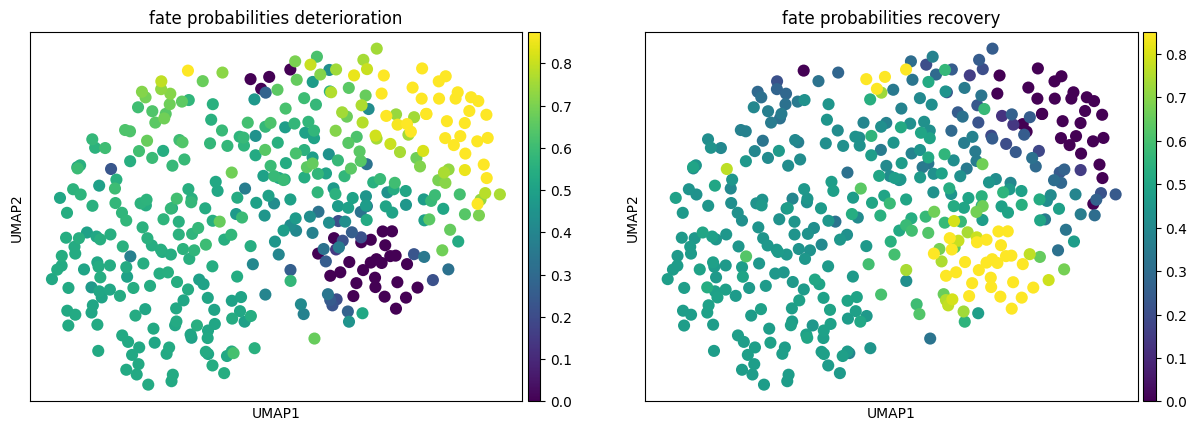

In [18]:
g.compute_fate_probabilities(solver="direct", use_petsc=False)
g.plot_fate_probabilities(basis="umap", same_plot=False)

Patients on the right of the embedding are committed to one fate: those near the deterioration state towards deterioration, those near the patients after cardiac surgery towards recovery.
Patients with a low pseudotime on the left have probabilities around 0.5, since from there a random walk can still go either way.

We store the probability of deterioration in `obs` and call the fate of patients with a probability between 0.4 and 0.6 undetermined.
We then check how well the probability of deterioration separates the patients who died from those who survived, compared with pseudotime and the admission scores.
Patients in the terminal states are left out, since they define the fates.

In [19]:
fate_probabilities = g.fate_probabilities
edata.obs["deterioration_probability"] = fate_probabilities["deterioration"].X.ravel()
edata.obs["fate"] = pd.cut(
    edata.obs["deterioration_probability"],
    [0, 0.4, 0.6, 1],
    labels=["recovery", "undetermined", "deterioration"],
    include_lowest=True,
)

transient = g.terminal_states.isna().to_numpy()
scores = edata.obs.loc[transient, ["deterioration_probability", "dpt_pseudotime", "SOFA", "SAPS-I"]]
scores.fillna(scores.median()).apply(lambda score: roc_auc_score(died[transient], score)).round(2).rename("AUC")

deterioration_probability    0.68
dpt_pseudotime               0.67
SOFA                         0.68
SAPS-I                       0.74
Name: AUC, dtype: float64

The probability of deterioration separates the patients who died from those who survived with an AUC of 0.68, as well as the SOFA score and slightly better than pseudotime, but worse than SAPS-I with 0.74.
The fates are therefore no better risk score than established ones; their value lies in showing which course a patient resembles.

:::{warning}
The fates depend on the random sample, the root, the number of macrostates and the graph.
On another random sample of 400 patients, the two terminal states differed less in mortality, and terminal states chosen directly by the outcome gave fate probabilities that did not separate the patients at all.
Treat the fates as a description of where similar patients went, not as a validated risk score, and check them on more patients before drawing conclusions.
:::

{func}`~ehrapy.plot.trajectories` shows how the patients with either fate differ over the 48 hours.

In [20]:
ep.pl.trajectories(
    edata, var_names=["GCS", "pH", "FiO2", "MAP"], groupby="fate", xlabel="hour", width=520, height=320
).cols(2)

:Layout
   .Overlay.Mean_of_GCS_over_time  :Overlay
      .Area.Recovery_left_parenthesis_n_equals_59_right_parenthesis        :Area   [time]   (GCS,GCS upper)
      .Curve.Recovery_left_parenthesis_n_equals_59_right_parenthesis       :Curve   [time]   (GCS)
      .Area.Undetermined_left_parenthesis_n_equals_222_right_parenthesis   :Area   [time]   (GCS,GCS upper)
      .Curve.Undetermined_left_parenthesis_n_equals_222_right_parenthesis  :Curve   [time]   (GCS)
      .Area.Deterioration_left_parenthesis_n_equals_114_right_parenthesis  :Area   [time]   (GCS,GCS upper)
      .Curve.Deterioration_left_parenthesis_n_equals_114_right_parenthesis :Curve   [time]   (GCS)
   .Overlay.Mean_of_pH_over_time   :Overlay
      .Area.Recovery_left_parenthesis_n_equals_59_right_parenthesis        :Area   [time]   (pH,pH upper)
      .Curve.Recovery_left_parenthesis_n_equals_59_right_parenthesis       :Curve   [time]   (pH)
      .Area.Undetermined_left_parenthesis_n_equals_222_right_parenthesis   :Area   [time]   (pH,pH upper)
      .Curve.Undetermined_left_parenthesis_n_equals_222_right_parenthesis  :Curve   [time]   (pH)
      .Area.Deterioration_left_parenthesis_n_equals_114_right_parenthesis  :Area   [time]   (pH,pH upper)
      .Curve.Deterioration_left_parenthesis_n_equals_114_right_parenthesis :Curve   [time]   (pH)
   .Overlay.Mean_of_FiO2_over_time :Overlay
      .Area.Recovery_left_parenthesis_n_equals_59_right_parenthesis        :Area   [time]   (FiO2,FiO2 upper)
      .Curve.Recovery_left_parenthesis_n_equals_59_right_parenthesis       :Curve   [time]   (FiO2)
      .Area.Undetermined_left_parenthesis_n_equals_222_right_parenthesis   :Area   [time]   (FiO2,FiO2 upper)
      .Curve.Undetermined_left_parenthesis_n_equals_222_right_parenthesis  :Curve   [time]   (FiO2)
      .Area.Deterioration_left_parenthesis_n_equals_114_right_parenthesis  :Area   [time]   (FiO2,FiO2 upper)
      .Curve.Deterioration_left_parenthesis_n_equals_114_right_parenthesis :Curve   [time]   (FiO2)
   .Overlay.Mean_of_MAP_over_time  :Overlay
      .Area.Recovery_left_parenthesis_n_equals_59_right_parenthesis        :Area   [time]   (MAP,MAP upper)
      .Curve.Recovery_left_parenthesis_n_equals_59_right_parenthesis       :Curve   [time]   (MAP)
      .Area.Undetermined_left_parenthesis_n_equals_222_right_parenthesis   :Area   [time]   (MAP,MAP upper)
      .Curve.Undetermined_left_parenthesis_n_equals_222_right_parenthesis  :Curve   [time]   (MAP)
      .Area.Deterioration_left_parenthesis_n_equals_114_right_parenthesis  :Area   [time]   (MAP,MAP upper)
      .Curve.Deterioration_left_parenthesis_n_equals_114_right_parenthesis :Curve   [time]   (MAP)

Patients heading for recovery arrive sedated from surgery with the lowest GCS and wake up within the first 15 hours, with a lower MAP throughout.
Patients heading for deterioration keep a GCS around 8 over all 48 hours and have a slightly lower pH, while the undetermined patients are mostly awake.
FiO2 hardly differs between the fates.

:::{seealso}
{func}`~ehrapy.tools.ncp` finds patterns of patients, variables and time jointly, without a graph between patients.
:::

## Conclusion

A patient graph from dynamic time warping of eight hourly variables ordered 395 ICU patients by a pseudotime that follows illness severity.
PAGA and CellRank split the sickest patients into two fates: persistent impairment of consciousness, in which half of the patients died, and the planned recovery after cardiac surgery, in which none did.
The fate probabilities describe this split but did not predict death better than SAPS-I and changed with the sample, so they are a way to explore courses of patients rather than a risk score.
The pseudotime and the probability of deterioration of every patient are in `obs`.